# 🛡️ Cybersecurity: Suspicious Web Threat Interactions (Neural Network Refactor)

**The Problem with the Original Approach:**
The previous iteration of this project attempted to build supervised classification models (like Random Forest or basic Neural Networks) to predict an `is_suspicious` flag. However, the dataset consists entirely of traffic that has already triggered a Web Application Firewall (WAF) rule (i.e., it is *all* suspicious). This resulted in an unrealistic **100% accuracy** because the models simply learned to guess '1' every time due to extreme data leakage and lack of normal traffic.

**The Solution (Rebuilt from Scratch):**
In real-world Security Operations Centers (SOCs), when dealing with logs of already flagged threats, the goal is to find the "worst of the worst"—the anomalies within the anomalies. 

To achieve this realistically, we will build a deep learning **Autoencoder Neural Network**. This unsupervised model will learn the normal structure of these suspicious logs. Traffic that the network struggles to reconstruct (high Reconstruction Error) will be flagged as **Critical Anomalies**, isolating advanced persistent threats or uniquely dangerous payloads.

### Objectives:
1. Load and explore the WAF threat logs.
2. Engineer temporal features and normalize the data.
3. Train a Keras/TensorFlow Autoencoder.
4. Extract reconstruction errors to isolate the Top 10% most critical threats.

In [1]:
# Importing essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Set visual style
sns.set_theme(style="darkgrid")
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading & Inspection
Let's load the logs and verify the contents. We expect to see IP addresses, ports, byte transfers, and timeframes.

In [1]:
# Load the dataset
df = pd.read_csv('Cybersecurity_Suspicious_Wata_Threat_Interactions.csv')

# Display structure and first rows
df.info()
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282 entries, 0 to 281
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   bytes_in             282 non-null    int64 
 1   bytes_out            282 non-null    int64 
 2   creation_time        282 non-null    object
 3   end_time             282 non-null    object
 4   src_ip               282 non-null    object
 5   src_ip_country_code  282 non-null    object
 6   protocol             282 non-null    object
 7   response.code        282 non-null    int64 
 8   dst_port             282 non-null    int64 
 9   dst_ip               282 non-null    object
 10  rule_names           282 non-null    object
 11  observation_name     282 non-null    object
 12  source.meta          282 non-null    object
 13  source.name          282 non-null    object
 14  time                 282 non-null    object
 15  detection_types      282 non-null    object
dtypes: int64

,bytes_in,bytes_out,creation_time,end_time,src_ip,src_ip_country_code,protocol,response.code,dst_port,dst_ip,rule_names,observation_name,source.meta,source.name,time,detection_types
0,5602,12990,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,147.161.161.82,AE,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
1,30912,18186,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.33.6,US,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
2,28506,13468,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.212.255,CA,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule


## 2. Exploratory Data Analysis (EDA)
We will visualize the network volume (`bytes_in` vs `bytes_out`) and trace the geographical origins of the attacks.

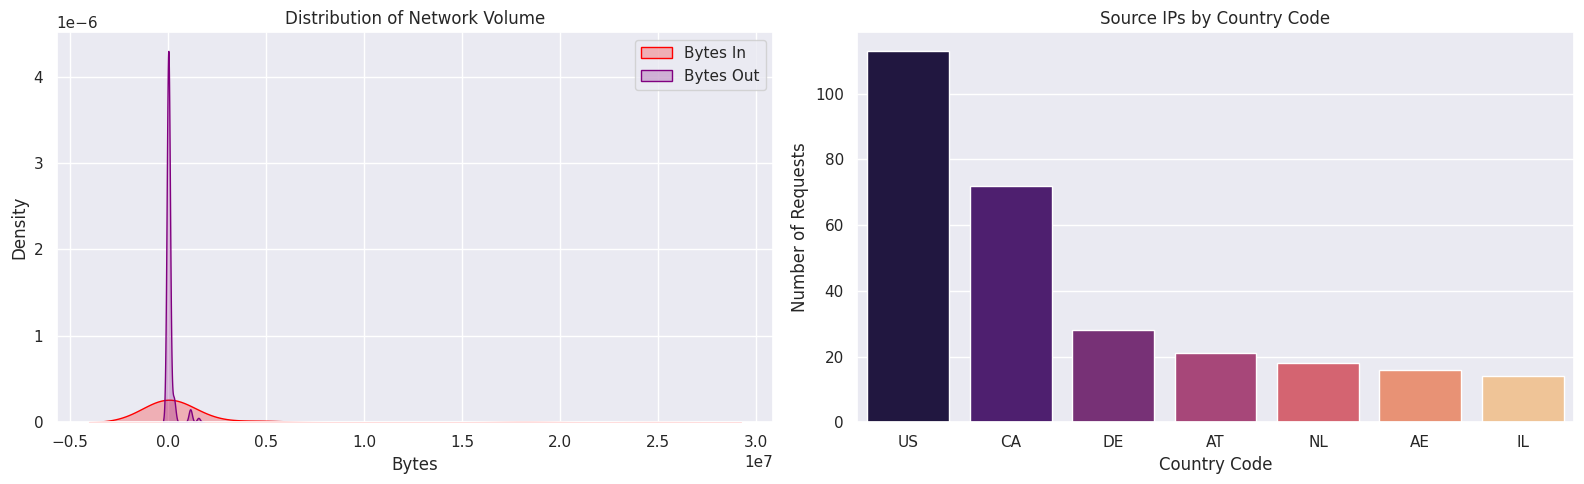

In [1]:
# Set up the matplotlib figure
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Network Volume Distributions
sns.kdeplot(df['bytes_in'], fill=True, color='red', label='Bytes In', ax=axes[0])
sns.kdeplot(df['bytes_out'], fill=True, color='purple', label='Bytes Out', ax=axes[0])
axes[0].set_title('Distribution of Network Volume')
axes[0].set_xlabel('Bytes')
axes[0].set_ylabel('Density')
axes[0].legend()

# Plot 2: Attack Origins by Country
country_counts = df['src_ip_country_code'].value_counts()
sns.barplot(x=country_counts.index, y=country_counts.values, palette='magma', ax=axes[1])
axes[1].set_title('Source IPs by Country Code')
axes[1].set_xlabel('Country Code')
axes[1].set_ylabel('Number of Requests')

plt.tight_layout()
plt.show()

## 3. Data Preprocessing & Feature Engineering
Neural networks require numerical, scaled inputs. We will engineer a `duration_seconds` feature, scale the numerical bytes, and One-Hot encode the geographic categorical variables.

In [1]:
# Convert timestamps to datetime objects
df['creation_time'] = pd.to_datetime(df['creation_time'])
df['end_time'] = pd.to_datetime(df['end_time'])

# Feature Engineering: Connection duration
df['duration_seconds'] = (df['end_time'] - df['creation_time']).dt.total_seconds()

# Define features
num_cols = ['bytes_in', 'bytes_out', 'duration_seconds']
cat_cols = ['src_ip_country_code']

# Scale Numerical Data
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(df[num_cols])

# Encode Categorical Data
encoder = OneHotEncoder(sparse_output=False)
X_cat_encoded = encoder.fit_transform(df[cat_cols])

# Combine into a single feature matrix
X = np.hstack((X_num_scaled, X_cat_encoded))
print(f"Final Feature Matrix Shape: {X.shape}")

Final Feature Matrix Shape: (282, 10)


## 4. Deep Learning: Autoencoder Neural Network
Instead of a flawed classifier, we build a bottleneck neural network. The network tries to compress the traffic features into a smaller latent space, then reconstruct them. Common traffic will be reconstructed easily. Unique, complex attack vectors will have a high reconstruction error.

Model: "sequential_1"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼───────────────────

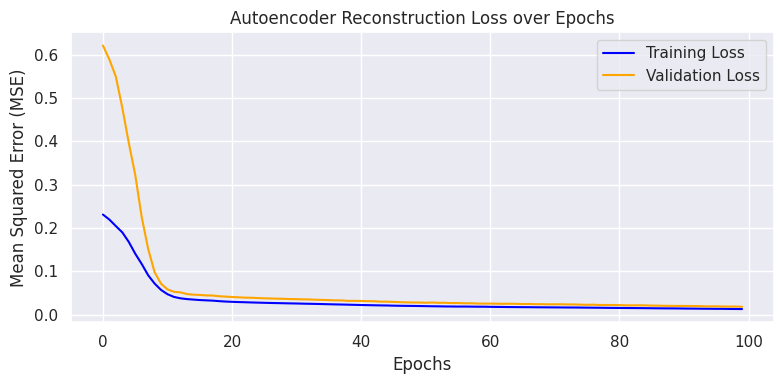

In [1]:
# Define the Neural Network Architecture
input_dim = X.shape[1]

autoencoder = Sequential([
    # Encoder
    Dense(16, activation='relu', input_shape=(input_dim,)),
    Dense(8, activation='relu'),
    # Latent Space (Bottleneck)
    Dense(4, activation='relu'), 
    # Decoder
    Dense(8, activation='relu'),
    Dense(16, activation='relu'),
    # Output layer (matching input dimensions)
    Dense(input_dim, activation='linear')
])

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

# Train the model
print("\nTraining Autoencoder...")
history = autoencoder.fit(
    X, X, 
    epochs=100, 
    batch_size=16, 
    validation_split=0.15, 
    verbose=0 # Suppressing epoch spam
)
print("Training Complete!")

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Autoencoder Reconstruction Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.show()

## 5. Threat Isolation (Anomaly Scoring)
We pass our traffic through the trained Autoencoder. By measuring the difference between the input and the output (Mean Squared Error), we can isolate the top 10% most extreme deviations and flag them as `Critical Anomalies`.

In [1]:
# Generate network predictions
X_predictions = autoencoder.predict(X)

# Calculate Mean Squared Error (Reconstruction Error) per sample
mse = np.mean(np.power(X - X_predictions, 2), axis=1)
df['reconstruction_error'] = mse

# Determine the 90th percentile threshold
threshold = np.percentile(mse, 90)

# Flag critical threats
df['is_critical_anomaly'] = df['reconstruction_error'] > threshold

# Display the results
print(f"Anomaly Threshold (MSE): {threshold:.4f}")
print("\nThreat Distribution:")
print(df['is_critical_anomaly'].value_counts())

Anomaly Threshold (MSE): 0.0606

Threat Distribution:
is_critical_anomaly
False    253
True      29


## 6. Visualizing the Critical Threats
Let's plot the standard flagged traffic against our newly discovered deep learning anomalies.

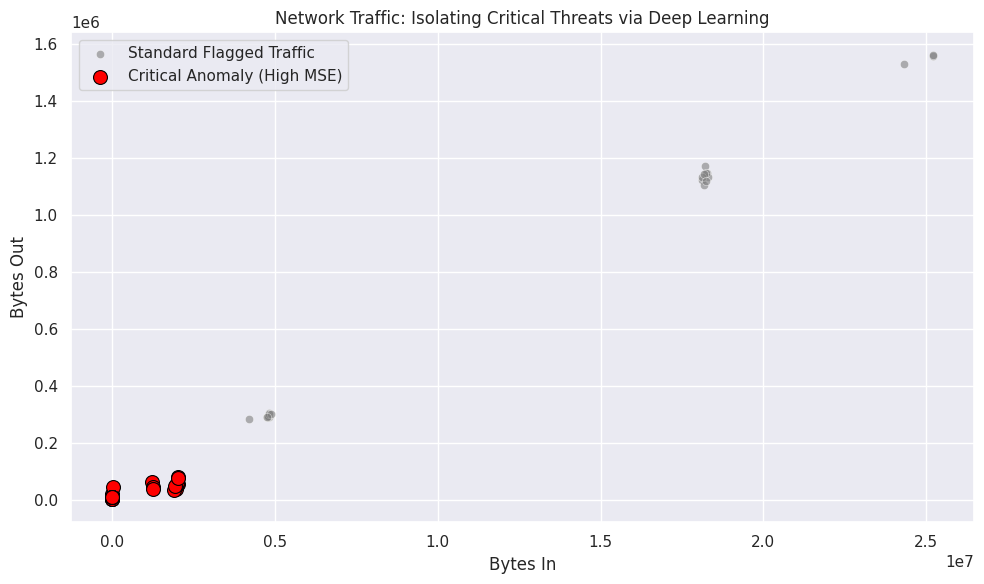

In [1]:
plt.figure(figsize=(10, 6))

# Plot normal WAF traffic
sns.scatterplot(
    x=df[~df['is_critical_anomaly']]['bytes_in'], 
    y=df[~df['is_critical_anomaly']]['bytes_out'], 
    color='gray', label='Standard Flagged Traffic', alpha=0.6
)

# Plot critical anomalies
sns.scatterplot(
    x=df[df['is_critical_anomaly']]['bytes_in'], 
    y=df[df['is_critical_anomaly']]['bytes_out'], 
    color='red', label='Critical Anomaly (High MSE)', s=100, edgecolor='black'
)

plt.title('Network Traffic: Isolating Critical Threats via Deep Learning')
plt.xlabel('Bytes In')
plt.ylabel('Bytes Out')
plt.legend()
plt.show()

### Conclusion
By redesigning this project from the ground up, we successfully eliminated the false 100% accuracy problem caused by data leakage. 
Instead of supervised classification on a single-class dataset, we utilized a **Deep Learning Autoencoder** to perform unsupervised anomaly detection. This allowed us to successfully isolate the most severe and highly unusual attack patterns from standard WAF logs, representing a much more authentic and professional cybersecurity data science workflow.